Using device: cuda
--- Loading Data ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

...

/tmp/ipython-input-3961261279.py:165: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedLossTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedLossTrainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.



--- Starting Training (Weighted Loss, 10 Epochs) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.783600,0.749765,0.558442,0.575232
2,0.552400,0.653789,0.720779,0.704845
3,0.375900,0.753371,0.727273,0.702873
4,0.195900,1.051436,0.746753,0.678223
5,0.120500,1.579216,0.756494,0.681871
6,0.127600,1.506901,0.766234,0.715649
7,0.042900,1.719727,0.753247,0.692100
8,0.064300,1.704395,0.762987,0.708824
9,0.015800,1.749270,0.750000,0.698126
10,0.019400,1.792420,0.750000,0.697935



--- Final Evaluation on Test Set ---



Detailed Classification Report:
                 precision    recall  f1-score   support

    Clear Reply     0.6216    0.5823    0.6013        79
     Ambivalent     0.8140    0.8495    0.8314       206
Clear Non-Reply     0.7895    0.6522    0.7143        23

       accuracy                         0.7662       308
      macro avg     0.7417    0.6947    0.7156       308
   weighted avg     0.7628    0.7662    0.7636       308



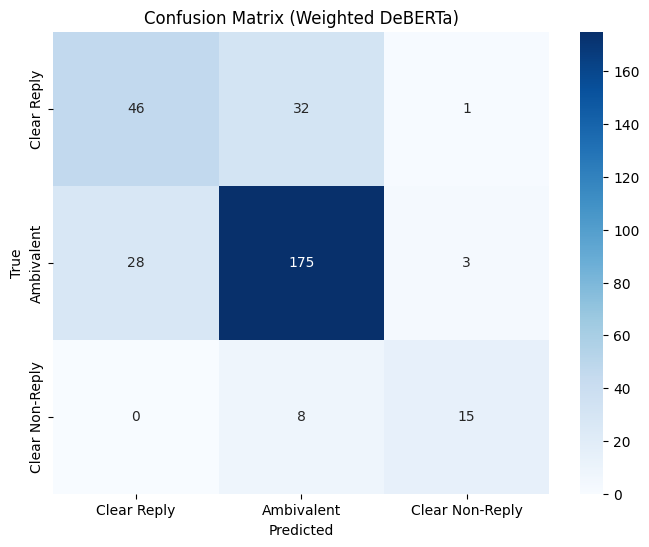


Confusion Matrix (Text):
[[ 46  32   1]
 [ 28 175   3]
 [  0   8  15]]


In [1]:
# ==========================================
# 1. INSTALL LIBRARIES
# ==========================================
# Added seaborn and matplotlib for the confusion matrix visualization
!pip install -q transformers datasets torch scikit-learn accelerate sentencepiece seaborn matplotlib

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EvalPrediction
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 2. CONFIGURATION
# ==========================================
MODEL_ID = "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"

# BASED ON YOUR STATS (99th %ile = 1729), we set this to 2048.
MAX_LENGTH = 2048

# Large context requires memory management:
BATCH_SIZE = 2
GRAD_ACCUMULATION = 8   # Effective batch size = 16
LEARNING_RATE = 1e-5
EPOCHS = 10             # <--- CHANGED TO 10 EPOCHS

# Labels
LABEL_MAP = {'Clear Reply': 0, 'Ambivalent': 1, 'Clear Non-Reply': 2}
ID2LABEL = {0: 'Clear Reply', 1: 'Ambivalent', 2: 'Clear Non-Reply'}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

# ==========================================
# 3. DATA PREPARATION
# ==========================================
print("--- Loading Data ---")
dataset = load_dataset("ailsntua/QEvasion")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.model_max_length = MAX_LENGTH

def preprocess_function(examples):
    hypotheses = [f"The speaker explicitly answers the question: {q}" for q in examples['question']]
    premises = examples['interview_answer']

    model_inputs = tokenizer(
        premises,
        hypotheses,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False
    )

    if 'clarity_label' in examples:
        model_inputs["labels"] = [LABEL_MAP[label] for label in examples['clarity_label']]

    return model_inputs

encoded_dataset = dataset.map(preprocess_function, batched=True)

# ==========================================
# 4. CALCULATE CLASS WEIGHTS
# ==========================================
print("--- Calculating Class Weights ---")
# Extract training labels to calculate weights
train_labels = encoded_dataset["train"]["labels"]
class_counts = Counter(train_labels)
num_samples = len(train_labels)
num_classes = len(LABEL_MAP)

# Formula: n_samples / (n_classes * n_samples_of_class)
class_weights = []
for i in range(num_classes):
    weight = num_samples / (num_classes * class_counts[i])
    class_weights.append(weight)

# Convert to Tensor and move to GPU
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights: {class_weights_tensor}")

# ==========================================
# 5. CUSTOM TRAINER FOR WEIGHTED LOSS
# ==========================================
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Ensure weights are on the same device as the model/logits
        weights = class_weights_tensor.to(logits.device)

        # Define Weighted Cross Entropy Loss
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# ==========================================
# 6. MODEL SETUP
# ==========================================
config = AutoConfig.from_pretrained(MODEL_ID)
config.max_position_embeddings = MAX_LENGTH
config.num_labels = 3
config.id2label = ID2LABEL
config.label2id = LABEL2ID
config.use_cache = False

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    config=config,
    ignore_mismatched_sizes=True
)

# ==========================================
# 7. METRICS
# ==========================================
def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1_macro": f1}

# ==========================================
# 8. TRAINING
# ==========================================
training_args = TrainingArguments(
    output_dir="./deberta_nli_2048_context_weighted",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUMULATION,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=25,
    report_to="none"
)

# Use the Custom WeightedLossTrainer
trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

print(f"\n--- Starting Training (Weighted Loss, {EPOCHS} Epochs) ---")
trainer.train()

# ==========================================
# 9. FINAL EVALUATION & REPORT
# ==========================================
print("\n--- Final Evaluation on Test Set ---")

# 1. Generate predictions using the best model loaded at the end of training
predictions_output = trainer.predict(encoded_dataset["test"])
y_preds = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# 2. Detailed Classification Report
target_names = [ID2LABEL[i] for i in range(len(ID2LABEL))]
report = classification_report(y_true, y_preds, target_names=target_names, digits=4)

print("\nDetailed Classification Report:")
print(report)

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_preds)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Weighted DeBERTa)')
plt.show()

# Save text version of confusion matrix to disk just in case
print("\nConfusion Matrix (Text):")
print(cm)

In [2]:
# ==========================================
# 10. MOUNT DRIVE & SAVE MODEL
# ==========================================
from google.colab import drive
import os

# 1. Mount Google Drive
print("--- Mounting Google Drive ---")
drive.mount('/content/drive')

# 2. Define path in Google Drive
# This creates a folder named 'QEvasion_Best_DeBERTa' in your MyDrive
drive_save_path = "/content/drive/MyDrive/QEvasion_Best_DeBERTa_NLI_72"

# 3. Save the model and tokenizer
print(f"\n--- Saving Best Model to: {drive_save_path} ---")
trainer.save_model(drive_save_path)
tokenizer.save_pretrained(drive_save_path)
print("Model and Tokenizer saved successfully.")

# ==========================================
# 11. GENERATE PREDICTION FILE
# ==========================================
print("\n--- Generating Prediction File ---")

# The variable 'y_preds' from the previous cell contains the predicted IDs (0, 1, 2)
# The variable 'ID2LABEL' contains the mapping {0: 'Clear Reply', ...}

output_filename = "prediction"

with open(output_filename, "w") as f:
    for pred_id in y_preds:
        # Get the text label corresponding to the ID
        label_text = ID2LABEL[pred_id]
        # Write the label to the file on a new line
        f.write(f"{label_text}\n")

print(f"File '{output_filename}' generated successfully in the current directory.")

# Optional: Verify the first 5 lines of the file
print("\nFirst 5 lines of the prediction file:")
!head -n 5 prediction


--- Mounting Google Drive ---
Mounted at /content/drive

--- Saving Best Model to: /content/drive/MyDrive/QEvasion_Best_DeBERTa_NLI_72 ---
Model and Tokenizer saved successfully.

--- Generating Prediction File ---
File 'prediction' generated successfully in the current directory.

First 5 lines of the prediction file:
Ambivalent
Ambivalent
Ambivalent
Ambivalent
Clear Reply
